In [2]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from IPython.display import Markdown

from IPython.display import Markdown, display
import pandas as pd

## About dataset

Customer churn is a fundamental problem for the telecommunication (Telco) industry. It is defined as the loss of customers moved from one Telco operator to another. If customer churn can be predicted in advance, such as “is this customer going to leave us within the next X months?”, Telco operators can apply business marketing policies to such churn customers to retain and increase the customer base. In particular, given millions of Telco customers, even reducing the 1% churn rate will lead to a significant profit increase.

We can roughly define the Churn analysis as the whole of analytical studies on “a customer”, “a product or service”, and “the probability of abandonment”. We aim to be aware of this situation (even the customer himself may not be aware of this situation) before the customer leaves us (approaching to leave) and then to take some preventive actions.

Telco churn data includes information about a fictitious telecom company that provided home phone and Internet services to 7,043 California customers in the third quarter. Which customers have left, stayed, or signed up for their service shows?

X is the independent variables - the variables we are using to make predictions

- customerID - unique value identifying customer
- gender - whether the customer is a male or a female
- SeniorCitizen - whether the customer is a senior citizen or not (1, 0)
- Partner - whether the customer has a partner or not (Yes, No)
- Dependents - whether the customer has dependents or not (Yes, No). A dependent is a person who relies on another as a primary source of income,
- tenure - number of months the customer has stayed with the company
- PhoneService - whether the customer has a phone service or not (Yes, No)
- MultipleLines - whether the customer has multiple lines or not (Yes, No, No phone service)
- InternetService - customer’s internet service provider (DSL, Fiber optic, No)
- OnlineSecurity - whether the customer has online security or not (Yes, No, No internet service)
- OnlineBackup - whether the customer has online backup or not (Yes, No, No internet service)
- DeviceProtection - whether the customer has device protection or not (Yes, No, No internet service)
- TechSupport - whether the customer has tech support or not (Yes, No, No internet service)
- StreamingTV - whether the customer has streaming TV or not (Yes, No, No internet service)
- StreamingMovies - whether the customer has streaming movies or not (Yes, No, No internet service)
- Contract - type of contract according to duration (Month-to-month, One year, Two year)
- PaperlessBilling - bills issued in paperless form (Yes, No)
- PaymentMethod - payment method used by customer (Electronic check, Mailed check, Credit card (automatic), Bank transfer (automatic))
- MonthlyCharges - amount of charge for service on monthly bases
- TotalCharges - cumulative charges for service during subscription (tenure) period

- Churn – output value, predict variable

---

Orginal data set:
https://www.kaggle.com/code/emineyetm/telco-customer-churn/notebook

Author of dataset:
https://www.kaggle.com/emineyetm


## EDA analysis goals:
- Understanding the data
- Removing information noise
- Potentially repairing the data
- Creating a dataset that allows for the creation of an ML model for predicting customer churn or retention

# 1. Technical data review

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
raw_df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    # show(raw_df)

## 1.1 Data info

In [5]:
info_df = pd.DataFrame({
    'Column': raw_df.columns,
    'No-null': raw_df.notnull().sum().values,
    'Unique values': raw_df.nunique().values,
    'Data type': raw_df.dtypes.values,
    'Percentege': (raw_df.nunique().values),
})

# Wyświetlenie tabeli
info_df

,Column,No-null,Unique values,Data type,Percentege
0,customerID,7043,7043,object,7043
1,gender,7043,2,object,2
2,SeniorCitizen,7043,2,int64,2
3,Partner,7043,2,object,2
4,Dependents,7043,2,object,2
5,tenure,7043,73,int64,73
6,PhoneService,7043,2,object,2
7,MultipleLines,7043,3,object,3
8,InternetService,7043,3,object,3
9,OnlineSecurity,7043,3,object,3


# 1.2 Statistical Summary

In [6]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
# HELPER FUNCTION

def value_chek(col):
    # display(Markdown(f"Column {col_name} have **{raw_df[col_name].nunique()}** unique valiuse: {raw_df[col_name].unique()}"))
    display(Markdown(f"## 🔹 {col}"))

    # Data Type
    print("Dtype:", raw_df[col].dtype)

    # Nulls
    print("Missing:", raw_df[col].isna().sum())

    # unique value
    print("Unique:", raw_df[col].nunique())

    print("-" * 40)

    if pd.api.types.is_numeric_dtype(raw_df[col]):
        print(raw_df[col].describe())
    else:
        vc = raw_df[col].value_counts()
        print(vc.head(10))

        # %
        print("\nPercentage:")
        print((vc / len(raw_df) * 100).head(10).round(2))

    print("\n\n")

# only for binary columns
def binary_numeric_check(col):
    # walidacja
    if not pd.api.types.is_numeric_dtype(raw_df[col]):
        print(f"{col} is NOT numeric")
        return
    
    if raw_df[col].nunique() != 2:
        print(f"{col} is NOT binary")
        return

    display(Markdown(f"## 🔘 {col} (binary numeric)"))

    print("Dtype:", raw_df[col].dtype)
    print("Missing:", raw_df[col].isna().sum())
    print("-" * 40)

    vc = raw_df[col].value_counts().sort_index()
    print("Count:")
    print(vc)

    print("\nPercentage:")
    print((vc / len(raw_df) * 100).round(2))

    print("\n\n")


def distribution(col):
    df_temp = raw_df[col].value_counts().reset_index()
    df_temp.columns = [col, 'count']

    fig = px.bar(
        df_temp,
        x=col,
        y='count',
        text='count',
        title=f'Distribution of {col}',
        color=col
    )

    fig.update_layout(width=900, height=550)
    fig.update_traces(textposition='outside')
    fig.show()

# CHECK COL WITH CHURN
def check_with_churn(col):
    print(f"Distribution of churn across {col}")
    return pd.crosstab(raw_df[col], raw_df['Churn'], normalize='index')

# CHECK COL WITH CHURN PLOT
def check_with_churn_plot(col):
    print(f"Distribution plot of churn across {col}")
    sns.countplot(x=col, hue='Churn', data=raw_df)

# 2 Analiza poszczególnych kolumn

- If the data shows any imbalance or obvious anomalies, a deeper analysis will be carried out.
- If the data appears balanced, further analysis is not necessary.

## 2.1 Analysis of columns with 2 values.

### 2.1.1 "Gender"

In [8]:
value_chek('gender')

## 🔹 gender

Dtype: object
Missing: 0
Unique: 2
----------------------------------------
Male      3555
Female    3488
Name: gender, dtype: int64

Percentage:
Male      50.48
Female    49.52
Name: gender, dtype: float64





The data looks in order

### 2.1.2 'Partner'

In [9]:
value_chek('Partner')

## 🔹 Partner

Dtype: object
Missing: 0
Unique: 2
----------------------------------------
No     3641
Yes    3402
Name: Partner, dtype: int64

Percentage:
No     51.7
Yes    48.3
Name: Partner, dtype: float64





The data looks in order

### 2.1.3 "Dependents"

In [10]:
value_chek('Dependents')

## 🔹 Dependents

Dtype: object
Missing: 0
Unique: 2
----------------------------------------
No     4933
Yes    2110
Name: Dependents, dtype: int64

Percentage:
No     70.04
Yes    29.96
Name: Dependents, dtype: float64





In [11]:
distribution('Dependents')

/home/krzysiek/miniconda3/envs/od_zera_do_ai_v2/lib/python3.11/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




The data still looks in order

### 2.1.4. ' SeniorCitizen'

In [12]:
# value_chek('SeniorCitizen')
binary_numeric_check('SeniorCitizen')

## 🔘 SeniorCitizen (binary numeric)

Dtype: int64
Missing: 0
----------------------------------------
Count:
0    5901
1    1142
Name: SeniorCitizen, dtype: int64

Percentage:
0    83.79
1    16.21
Name: SeniorCitizen, dtype: float64





#### The data does not represent the older age group well.

### The ratio of the age group to the "Chrun" column representing departures

In [13]:
check_with_churn('SeniorCitizen')

Distribution of churn across SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


Distribution plot of churn across SeniorCitizen


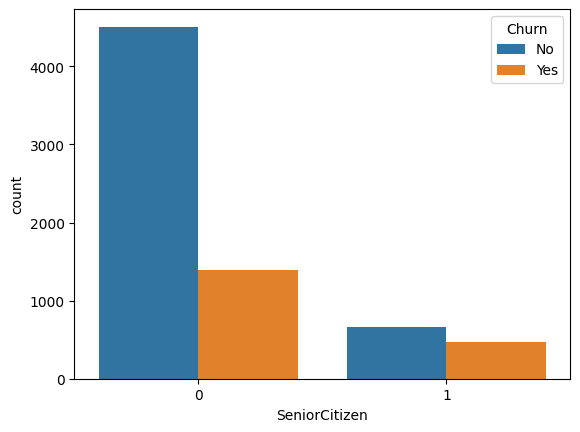

In [14]:
check_with_churn_plot('SeniorCitizen')

#### 🔥 Elderly customers exhibit a significantly higher churn rate (~42%) compared to non-elderly users (~24%).
#### 🔥 There is a clear difference in churn rates between groups, indicating that this feature may be important for prediction.

### 2.1.5 'PhoneService'

In [15]:
value_chek('PhoneService')

## 🔹 PhoneService

Dtype: object
Missing: 0
Unique: 2
----------------------------------------
Yes    6361
No      682
Name: PhoneService, dtype: int64

Percentage:
Yes    90.32
No      9.68
Name: PhoneService, dtype: float64





In [16]:
distribution('PhoneService')

In [17]:
check_with_churn('PhoneService')

Distribution of churn across PhoneService


Churn,No,Yes
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096


Distribution plot of churn across PhoneService


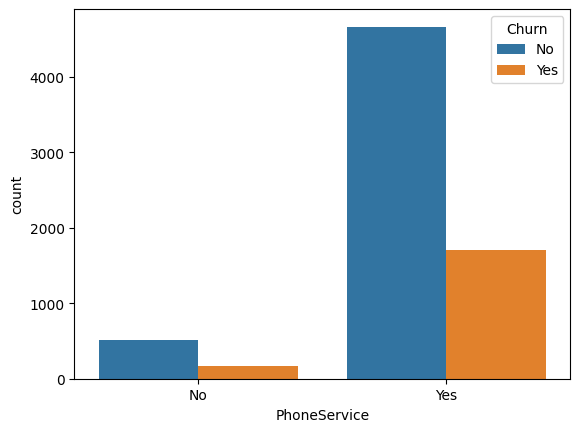

In [18]:
check_with_churn_plot('PhoneService')

### ❄️ The PhoneService feature has a negligible impact on churn, with similar churn rates observed across both groups (~25–27%).

## 2.2 Analysis of columns with 3 values.

### 2.1.6 'PaperlessBilling'

In [19]:
value_chek('PaperlessBilling')

## 🔹 PaperlessBilling

Dtype: object
Missing: 0
Unique: 2
----------------------------------------
Yes    4171
No     2872
Name: PaperlessBilling, dtype: int64

Percentage:
Yes    59.22
No     40.78
Name: PaperlessBilling, dtype: float64





In [20]:
distribution('PaperlessBilling')

In [21]:
check_with_churn('PaperlessBilling')

Distribution of churn across PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


Distribution plot of churn across PaperlessBilling


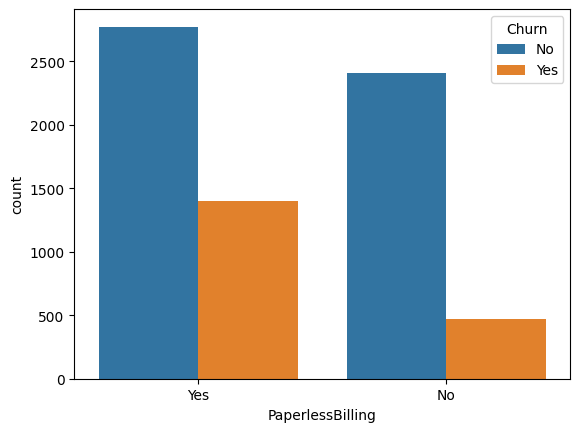

In [22]:
check_with_churn_plot('PaperlessBilling')

### Customers using paperless billing exhibit a significantly higher churn rate compared to those receiving paper bills.

## 2.2 Analysis of columns with 3 values.

### 2.2.1 'MultipleLines' 

In [23]:
value_chek('MultipleLines')

## 🔹 MultipleLines

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64

Percentage:
No                  48.13
Yes                 42.18
No phone service     9.68
Name: MultipleLines, dtype: float64





In [24]:
distribution('MultipleLines')

In [25]:
check_with_churn('MultipleLines')

Distribution of churn across MultipleLines


Churn,No,Yes
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


Distribution plot of churn across MultipleLines


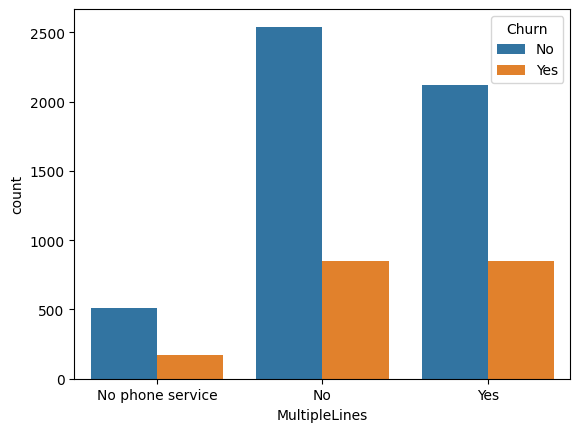

In [26]:
check_with_churn_plot('MultipleLines')

## ⚖️ Redundancy check between 'PhoneService' and 'MultipleLines'
The two features are fully redundant — the category "No phone service" in 'MultipleLines' corresponds exactly to 'PhoneService = No'.

In [27]:
(raw_df['MultipleLines'] == 'No phone service').equals(raw_df['PhoneService'] == 'No')

True

### 2.2.2 'InternetService'

In [28]:
value_chek('InternetService')

## 🔹 InternetService

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

Percentage:
Fiber optic    43.96
DSL            34.37
No             21.67
Name: InternetService, dtype: float64





In [29]:
distribution('InternetService')

In [30]:
check_with_churn('InternetService')

Distribution of churn across InternetService


Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


Distribution plot of churn across InternetService


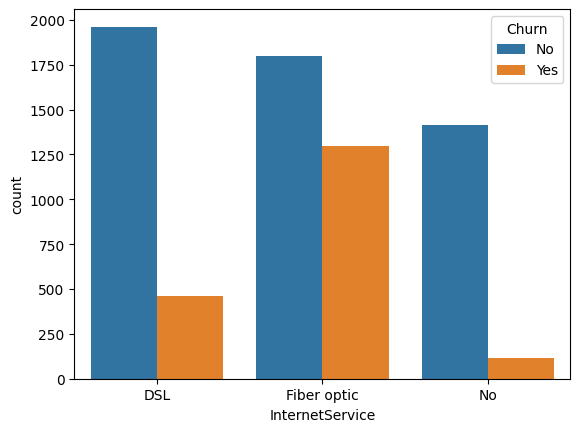

In [31]:
check_with_churn_plot('InternetService')

### 🔥 The InternetService feature shows a strong relationship with churn, with fiber optic users exhibiting a much higher churn rate (~42%) compared to DSL (~19%) and no internet users (~7%).

In [32]:
def value_summary(col):
    if raw_df[col].nunique() <= 5:
        vc = raw_df[col].value_counts(normalize=True) * 100
        return ', '.join([f"{idx}: {round(val,1)}%" for idx, val in vc.items()])
    else:
        return ''

info_df = pd.DataFrame({
    'Column': raw_df.columns,
    'No-null': raw_df.notnull().sum().values,
    'Unique values': raw_df.nunique().values,
    'Data type': raw_df.dtypes.values,
})

info_df['Distribution'] = info_df['Column'].apply(value_summary)

info_df

,Column,No-null,Unique values,Data type,Distribution
0,customerID,7043,7043,object,
1,gender,7043,2,object,"Male: 50.5%, Female: 49.5%"
2,SeniorCitizen,7043,2,int64,"0: 83.8%, 1: 16.2%"
3,Partner,7043,2,object,"No: 51.7%, Yes: 48.3%"
4,Dependents,7043,2,object,"No: 70.0%, Yes: 30.0%"
5,tenure,7043,73,int64,
6,PhoneService,7043,2,object,"Yes: 90.3%, No: 9.7%"
7,MultipleLines,7043,3,object,"No: 48.1%, Yes: 42.2%, No phone service: 9.7%"
8,InternetService,7043,3,object,"Fiber optic: 44.0%, DSL: 34.4%, No: 21.7%"
9,OnlineSecurity,7043,3,object,"No: 49.7%, Yes: 28.7%, No internet service: 21.7%"


### 2.2.3 'OnlineSecurity'

In [33]:
value_chek('OnlineSecurity')

## 🔹 OnlineSecurity

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                     3498
Yes                    2019
No internet service    1526
Name: OnlineSecurity, dtype: int64

Percentage:
No                     49.67
Yes                    28.67
No internet service    21.67
Name: OnlineSecurity, dtype: float64





In [34]:
distribution('OnlineSecurity')

In [35]:
check_with_churn('OnlineSecurity')

Distribution of churn across OnlineSecurity


Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


Distribution plot of churn across OnlineSecurity


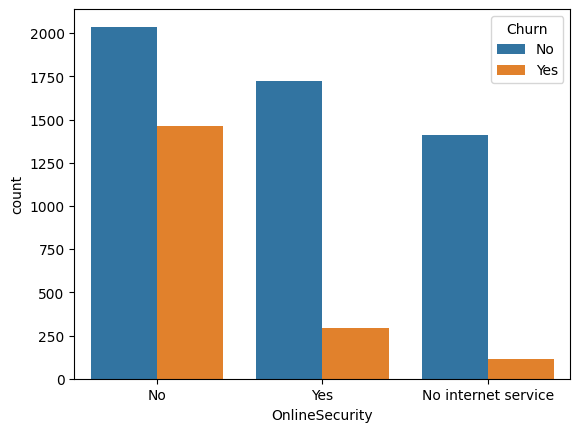

In [36]:
check_with_churn_plot('OnlineSecurity')

### Customers with OnlineSecurity exhibit a significantly lower churn rate (~15%) compared to those without it (~42%), suggesting a strong relationship between this feature and customer retention.

# 2.2.4 'OnlineBackup'

In [37]:
value_chek('OnlineBackup')

## 🔹 OnlineBackup

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                     3088
Yes                    2429
No internet service    1526
Name: OnlineBackup, dtype: int64

Percentage:
No                     43.84
Yes                    34.49
No internet service    21.67
Name: OnlineBackup, dtype: float64





In [38]:
distribution('OnlineBackup')

In [39]:
check_with_churn('OnlineBackup')

Distribution of churn across OnlineBackup


Churn,No,Yes
OnlineBackup,,
No,0.600712,0.399288
No internet service,0.925950,0.074050
Yes,0.784685,0.215315


Distribution plot of churn across OnlineBackup


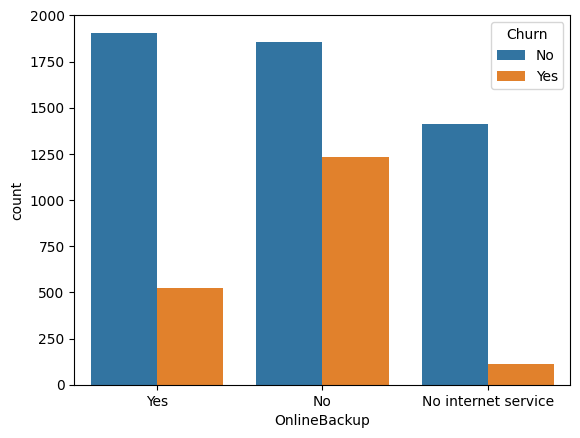

In [40]:
check_with_churn_plot('OnlineBackup')

### Customers with OnlineBackup exhibit a lower churn rate compared to those without it, indicating that additional services may contribute to customer retention.

### 2.2.5 'DeviceProtection'

In [41]:
value_chek('DeviceProtection')

## 🔹 DeviceProtection

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                     3095
Yes                    2422
No internet service    1526
Name: DeviceProtection, dtype: int64

Percentage:
No                     43.94
Yes                    34.39
No internet service    21.67
Name: DeviceProtection, dtype: float64





In [42]:
distribution('DeviceProtection')

In [43]:
check_with_churn('DeviceProtection')

Distribution of churn across DeviceProtection


Churn,No,Yes
DeviceProtection,,
No,0.608724,0.391276
No internet service,0.925950,0.074050
Yes,0.774979,0.225021


Distribution plot of churn across DeviceProtection


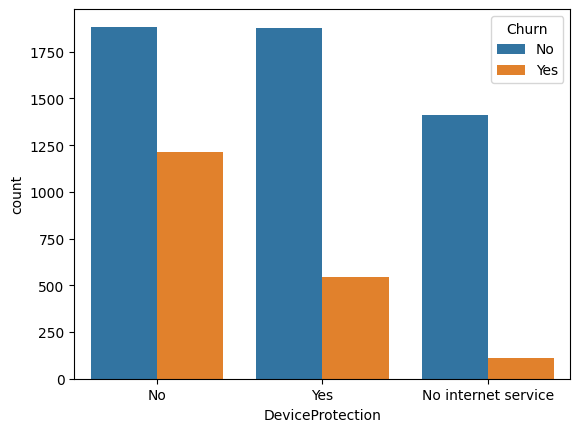

In [44]:
check_with_churn_plot('DeviceProtection')

### Customers with DeviceProtection exhibit a lower churn rate (~22%) compared to those without it (~39%).

### 2.2.6 'TechSupport'

In [45]:
value_chek('TechSupport')

## 🔹 TechSupport

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                     3473
Yes                    2044
No internet service    1526
Name: TechSupport, dtype: int64

Percentage:
No                     49.31
Yes                    29.02
No internet service    21.67
Name: TechSupport, dtype: float64





In [46]:
distribution('TechSupport')

In [47]:
check_with_churn('TechSupport')

Distribution of churn across TechSupport


Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


Distribution plot of churn across TechSupport


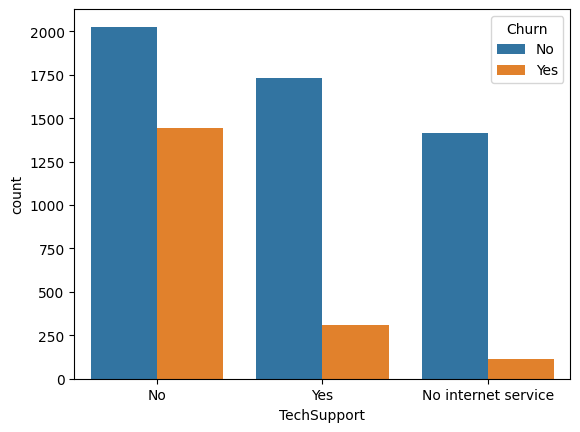

In [48]:
check_with_churn_plot('TechSupport')

### Customers with TechSupport exhibit a significantly lower churn rate compared to those without it.

## 🔥 META-INSIGHT

### Several additional service features (e.g., OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport) consistently show lower churn rates among customers who use them.

### 2.2.7 'StreamingTV'

In [49]:
value_chek('StreamingTV')

## 🔹 StreamingTV

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                     2810
Yes                    2707
No internet service    1526
Name: StreamingTV, dtype: int64

Percentage:
No                     39.90
Yes                    38.44
No internet service    21.67
Name: StreamingTV, dtype: float64





In [50]:
distribution('StreamingTV')

### 🔥 The StreamingTV feature is relatively balanced among customers with internet service, while a separate group (~22%) does not have internet access.

In [51]:
check_with_churn('StreamingTV')

Distribution of churn across StreamingTV


Churn,No,Yes
StreamingTV,,
No,0.664769,0.335231
No internet service,0.925950,0.074050
Yes,0.699298,0.300702


Distribution plot of churn across StreamingTV


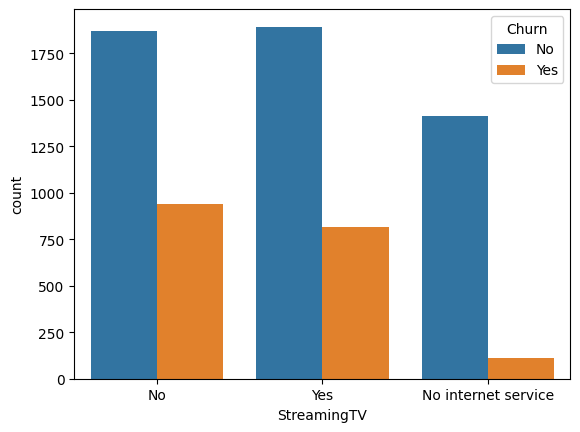

In [52]:
check_with_churn_plot('StreamingTV')

### ❄️ Customers who do not use StreamingTV show a slightly higher churn rate (~33%) compared to users (~30%), indicating a weak relationship.

## 2.2.8 StreamingMovies

In [53]:
value_chek('StreamingMovies')

## 🔹 StreamingMovies

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
No                     2785
Yes                    2732
No internet service    1526
Name: StreamingMovies, dtype: int64

Percentage:
No                     39.54
Yes                    38.79
No internet service    21.67
Name: StreamingMovies, dtype: float64





In [54]:
distribution('StreamingMovies')

In [55]:
check_with_churn('StreamingMovies')

Distribution of churn across StreamingMovies


Churn,No,Yes
StreamingMovies,,
No,0.663196,0.336804
No internet service,0.925950,0.074050
Yes,0.700586,0.299414


Distribution plot of churn across StreamingMovies


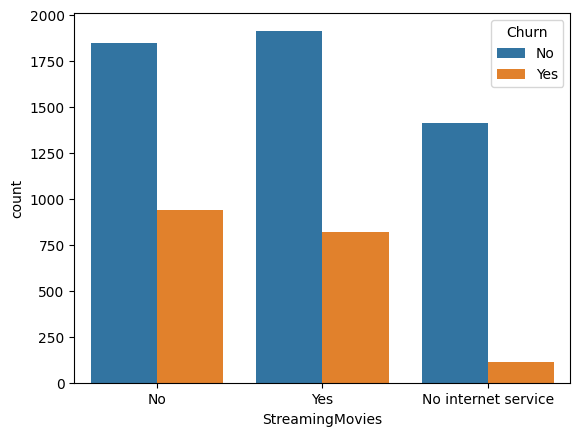

In [56]:
check_with_churn_plot('StreamingMovies')

###  ❄️ The StreamingMovies feature shows only a minor difference in churn rates between groups, indicating a weak relationship.
### Streaming-related features show only a weak relationship with churn.

## 2.2.9 'Contract'

In [57]:
value_chek('Contract')

## 🔹 Contract

Dtype: object
Missing: 0
Unique: 3
----------------------------------------
Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

Percentage:
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: Contract, dtype: float64





In [58]:
distribution('Contract')

In [59]:
check_with_churn('Contract')

Distribution of churn across Contract


Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Distribution plot of churn across Contract


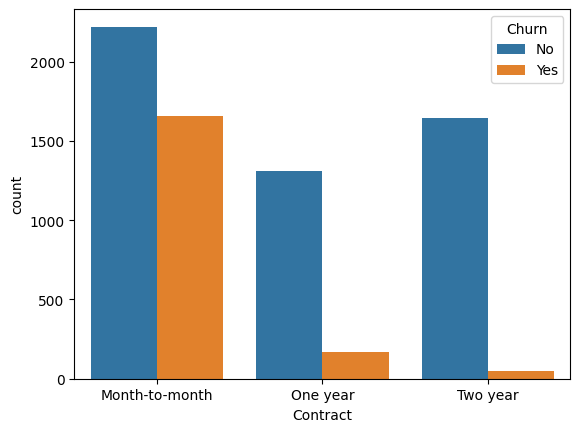

In [60]:
check_with_churn_plot('Contract')

## 🔥 Customers with month-to-month contracts exhibit a significantly higher churn rate compared to those with longer-term contracts.

## 2.3 Analysis of columns with 4 values and more.

### 2.3.1 'PaymentMethod'

In [61]:
value_chek('PaymentMethod')

## 🔹 PaymentMethod

Dtype: object
Missing: 0
Unique: 4
----------------------------------------
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

Percentage:
Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: PaymentMethod, dtype: float64





In [62]:
distribution('PaymentMethod')

In [63]:
check_with_churn('PaymentMethod')

Distribution of churn across PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


Distribution plot of churn across PaymentMethod


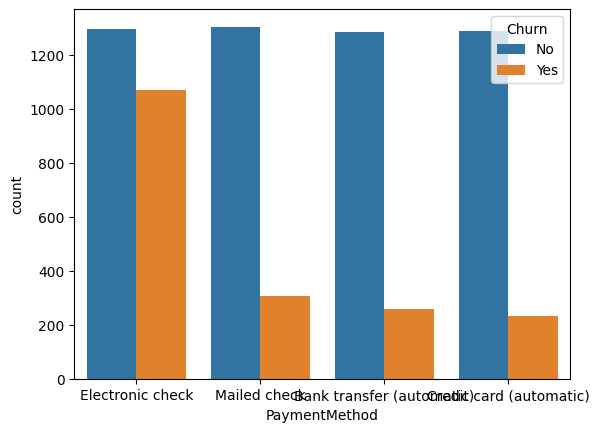

In [64]:
check_with_churn_plot('PaymentMethod')

## 🔥 The PaymentMethod feature shows a strong relationship with churn, with electronic check users exhibiting a significantly higher churn rate.

### 2.3.2 'tenure'

In [65]:
value_chek('tenure')

## 🔹 tenure

Dtype: int64
Missing: 0
Unique: 73
----------------------------------------
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64





In [66]:
distribution('tenure')

### The distribution of tenure appears bimodal, with a high concentration of both new customers and long-term users, suggesting the presence of distinct customer segments.

<Axes: xlabel='Churn', ylabel='tenure'>

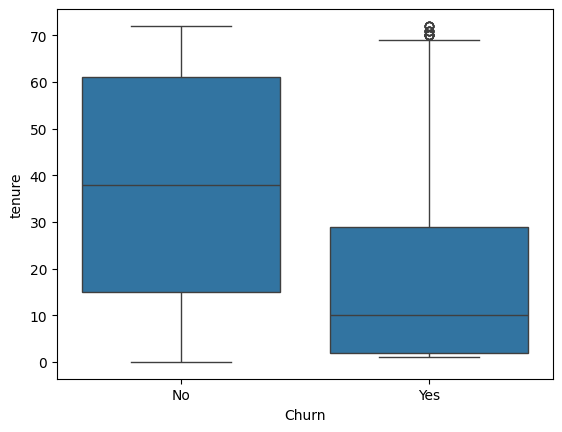

In [67]:
sns.boxplot(x='Churn', y='tenure', data=raw_df)

### Customers who churn tend to have significantly lower tenure, with most churn occurring within the first 30 months, while long-term customers are much more likely to stay.
### 🔥 The longer a customer stays with a company, the lower the likelihood of churn.

#### * The tenure feature was binned into quartiles using pd.qcut to examine how churn rates change across different stages of the customer lifecycle.

In [68]:
pd.qcut(raw_df['tenure'], 4)

0       (-0.001, 9.0]
1        (29.0, 55.0]
2       (-0.001, 9.0]
3        (29.0, 55.0]
4       (-0.001, 9.0]
            ...      
7038      (9.0, 29.0]
7039     (55.0, 72.0]
7040      (9.0, 29.0]
7041    (-0.001, 9.0]
7042     (55.0, 72.0]
Name: tenure, Length: 7043, dtype: category
Categories (4, interval[float64, right]): [(-0.001, 9.0] < (9.0, 29.0] < (29.0, 55.0] < (55.0, 72.0]]

In [69]:
pd.crosstab(pd.qcut(raw_df['tenure'], 4), raw_df['Churn'], normalize='index')

Churn,No,Yes
tenure,,
"(-0.001, 9.0]",0.502157,0.497843
"(9.0, 29.0]",0.716618,0.283382
"(29.0, 55.0]",0.811518,0.188482
"(55.0, 72.0]",0.922507,0.077493


## 🔥 The probability of churn decreases consistently with increasing tenure, indicating a strong negative relationship between customer tenure and churn.

<Axes: xlabel='tenure', ylabel='Count'>

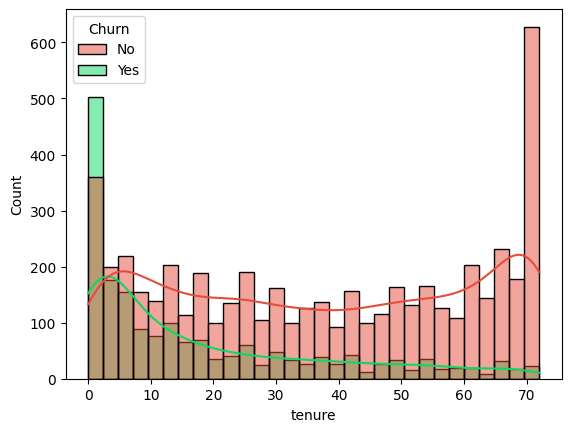

In [70]:
sns.histplot(
    data=raw_df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    palette=['#e74c3c', "#0dd862"]  # czerwony vs zielony
)

### The distribution of tenure by churn status indicates that churn is most prevalent among customers with low tenure, while long-term customers exhibit a much lower likelihood of leaving, suggesting a strong negative relationship between tenure and churn.

### 2.3.3 'MonthlyCharges'

In [71]:
value_chek('MonthlyCharges')

## 🔹 MonthlyCharges

Dtype: float64
Missing: 0
Unique: 1585
----------------------------------------
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64





### The MonthlyCharges variable exhibits high variability, as reflected by a relatively large standard deviation (~30) compared to the mean (~65), suggesting diverse pricing tiers among customers.

In [72]:
fig = px.histogram(
    raw_df,
    x='MonthlyCharges',
    nbins=30,
    title='Distribution of Monthly Charges'
)

fig.update_traces(
    marker_color='royalblue',
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=500,
    template='plotly_white'  # 🔥 ważne
)

fig.show()

In [73]:
distribution('MonthlyCharges')

#### The MonthlyCharges variable was segmented into four quantile-based bins using pd.qcut, ensuring an equal number of observations in each group for more balanced comparison of churn rates.

In [74]:
raw_df['MonthlyCharges_bin'] = pd.cut(raw_df['MonthlyCharges'], bins=10)
raw_df['MonthlyCharges_bin'] = pd.qcut(raw_df['MonthlyCharges'], 4)

In [75]:
pd.crosstab(
    raw_df['MonthlyCharges_bin'],
    raw_df['Churn'],
    normalize='index'
)

Churn,No,Yes
MonthlyCharges_bin,,
"(18.249, 35.5]",0.887628,0.112372
"(35.5, 70.35]",0.754247,0.245753
"(70.35, 89.85]",0.624929,0.375071
"(89.85, 118.75]",0.671217,0.328783


#### Customers with higher monthly charges generally exhibit higher churn rates, with the highest churn observed in the mid-to-high pricing range (~70–90), suggesting a non-linear relationship.

#### 'MonthlyCharges' Boxplot

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

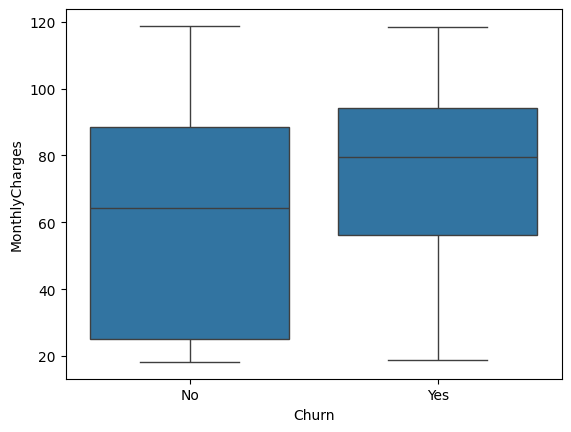

In [76]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=raw_df)

#### Customers who churn tend to have higher monthly charges compared to those who stay

### 'MonthlyCharges_bin' Barplot

Distribution plot of churn across MonthlyCharges_bin


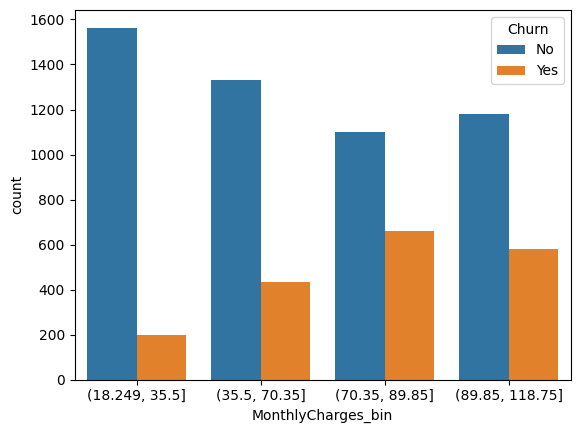

In [77]:
check_with_churn_plot('MonthlyCharges_bin')

### 🔥 The analysis of MonthlyCharges shows that churn increases with higher pricing levels, peaking in the mid-to-high range, and slightly decreasing for the highest price group, indicating a non-linear relationship.

## 2.3.4 'TotalCharges'

In [78]:
# raw_df[raw_df['TotalCharges']] = raw_df['TotalCharges'].astype(float)2f

The 'TotalCharges' column has been converted to numeric values ​​and rounded to 2 decimal places

In [79]:
raw_df['TotalCharges'] = pd.to_numeric(raw_df['TotalCharges'], errors='coerce').round(2)
# raw_df['TotalCharges'] = raw_df['TotalCharges'].round(2)

In [80]:
value_chek('TotalCharges')

## 🔹 TotalCharges

Dtype: float64
Missing: 11
Unique: 6530
----------------------------------------
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64





In [81]:
fig = px.histogram(
    raw_df,
    x='TotalCharges',
    nbins=30,
    title='Distribution of Monthly Charges'
)

fig.update_traces(
    marker_color='royalblue',
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=500,
    template='plotly_white'  # 🔥 ważne
)

fig.show()

The distribution of TotalCharges is right-skewed, with a large concentration of customers having low total charges and a long tail representing high-value, long-term customers.

The 'TotalCharges' variable was segmented into four quantile-based bins using pd.qcut, ensuring each group contains a similar number of observations for balanced comparison of churn rates.

In [82]:
raw_df['TotalCharges_bin'] = pd.qcut(raw_df['TotalCharges'], 4)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

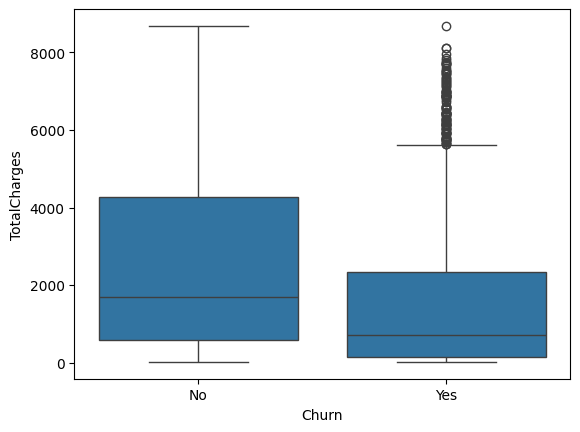

In [83]:
sns.boxplot(x='Churn', y='TotalCharges', data=raw_df)

#### Customers who churn tend to have lower total charges, while long-term customers with higher accumulated charges are more likely to stay.
#### Although a few high-value customers churn, they represent exceptions rather than the general pattern.

In [84]:
pd.crosstab(
    raw_df['TotalCharges_bin'],
    raw_df['Churn'],
    normalize='index'
)

Churn,No,Yes
TotalCharges_bin,,
"(18.799, 401.45]",0.565415,0.434585
"(401.45, 1397.475]",0.746871,0.253129
"(1397.475, 3794.738]",0.769625,0.230375
"(3794.738, 8684.8]",0.854949,0.145051


### Customers with lower total charges are significantly more likely to churn, while those with higher accumulated charges are more likely to stay.

Distribution plot of churn across TotalCharges_bin


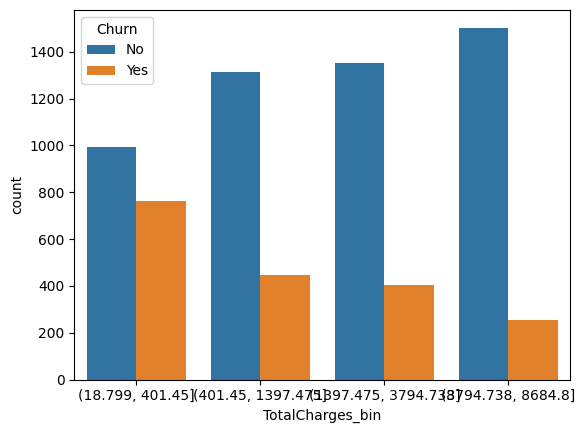

In [85]:
check_with_churn_plot('TotalCharges_bin')

### 2.3.5 Comparison between 'TotalCharges_bin' and tenure (bins)

In [86]:
pd.crosstab(
    raw_df['TotalCharges_bin'],
    raw_df['Churn'],
    normalize='index'
)

Churn,No,Yes
TotalCharges_bin,,
"(18.799, 401.45]",0.565415,0.434585
"(401.45, 1397.475]",0.746871,0.253129
"(1397.475, 3794.738]",0.769625,0.230375
"(3794.738, 8684.8]",0.854949,0.145051


In [87]:
pd.crosstab(pd.qcut(raw_df['tenure'], 4), raw_df['Churn'], normalize='index')

Churn,No,Yes
tenure,,
"(-0.001, 9.0]",0.502157,0.497843
"(9.0, 29.0]",0.716618,0.283382
"(29.0, 55.0]",0.811518,0.188482
"(55.0, 72.0]",0.922507,0.077493


#### A comparison between TotalCharges_bin and tenure bins reveals a very similar pattern, where churn decreases as both total charges and customer tenure increase. This is expected, as TotalCharges is strongly influenced by tenure. While both features capture a similar trend, TotalCharges may additionally reflect differences in pricing, providing slightly more nuanced information.

In [88]:
info_df = pd.DataFrame({
    'Column': raw_df.columns,
    'No-null': raw_df.notnull().sum().values,
    'Unique values': raw_df.nunique().values,
    'Data type': raw_df.dtypes.values,
})

# Wyświetlenie tabeli
info_df

,Column,No-null,Unique values,Data type
0,customerID,7043,7043,object
1,gender,7043,2,object
2,SeniorCitizen,7043,2,int64
3,Partner,7043,2,object
4,Dependents,7043,2,object
5,tenure,7043,73,int64
6,PhoneService,7043,2,object
7,MultipleLines,7043,3,object
8,InternetService,7043,3,object
9,OnlineSecurity,7043,3,object


## 2.5 'Churn' trget check

In [89]:
raw_df['Churn'].value_counts(normalize=True) * 100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

### The target variable (Churn) is moderately imbalanced, with a higher proportion of customers staying compared to those who churn.

## 3 Outliners

In [90]:
def detect_outliers(col):
    Q1 = raw_df[col].quantile(0.25)
    Q3 = raw_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return raw_df[(raw_df[col] < lower) | (raw_df[col] > upper)]

In [91]:
detect_outliers('TotalCharges').shape

(0, 23)

No significant outliers were detected in the dataset using the IQR method, indicating that the data does not contain extreme values that would require removal or treatment.

## Corelation matrix

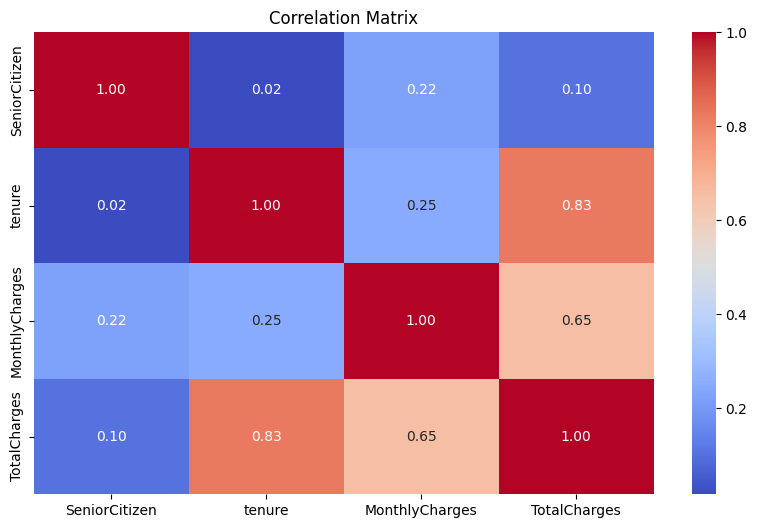

In [92]:
num_cols = raw_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## ✅ Main findings

### The correlation matrix reveals a strong positive relationship between tenure and 'TotalCharges' (0.83), indicating that these features carry highly overlapping information.

## 🔥 Redundancy insight

### 'TotalCharges' is also moderately correlated with 'MonthlyCharges' (0.65), confirming that it is largely derived from both tenure and monthly payments, and may therefore be considered redundant.

## 💡 Independent feature

### 'SeniorCitizen' shows very weak correlation with other numerical features, suggesting it provides independent information.

## 🔧 Decision for modeling

### Due to the high correlation with other variables, 'TotalCharges' may be removed to reduce redundancy and simplify the model without significant loss of information.

### The PhoneService feature was removed due to redundancy, as its information is fully captured by the MultipleLines variable.

## ❌

### The customerID variable was excluded from the analysis since it is a unique identifier and does not contribute to the predictive performance of the model.

## 🧠 EDA Conclusions

The dataset was generally clean, with no significant missing values or critical data quality issues, except for minor inconsistencies in the TotalCharges column, which were handled appropriately.


Several features showed strong relationships with churn, particularly tenure, Contract, and MonthlyCharges, indicating their high predictive potential.


Customers with shorter tenure and higher monthly charges were more likely to churn, while long-term customers exhibited significantly lower churn rates.


Some features, such as TotalCharges, were found to be highly correlated with other variables, suggesting redundancy and leading to their removal from the final model.


Additionally, non-informative features like customerID were excluded, while categorical variables were identified for appropriate encoding.

In [93]:
info_df = pd.DataFrame({
    'Column': raw_df.columns,
    'No-null': raw_df.notnull().sum().values,
    'Unique values': raw_df.nunique().values,
    'Data type': raw_df.dtypes.values,
})

# Wyświetlenie tabeli
info_df

,Column,No-null,Unique values,Data type
0,customerID,7043,7043,object
1,gender,7043,2,object
2,SeniorCitizen,7043,2,int64
3,Partner,7043,2,object
4,Dependents,7043,2,object
5,tenure,7043,73,int64
6,PhoneService,7043,2,object
7,MultipleLines,7043,3,object
8,InternetService,7043,3,object
9,OnlineSecurity,7043,3,object


### 💾 Saving the finished dataframe for ML classification

In [94]:
cols_to_drop = [
    'customerID',
    'PhoneService',
    'TotalCharges',
    'MonthlyCharges_bin',
    'TotalCharges_bin'
]

ml_df = raw_df.drop(columns=cols_to_drop)

In [95]:
ml_df.to_csv('telco_churn_clean.csv', index=False)

In [96]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  MonthlyCharges    7043 non-null   float64


The variable dependencies are moderately unbalanced (70/30), but it contains equipment items in both classes to be useful in the model.

Dependests: moderate unbalance, will not distort the model  to BIN